<a href="https://colab.research.google.com/github/JuanCarlosAL91/deep-learning-2-TdeA/blob/main/IA_DB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Base de datos inteligencia artificial**


**Base de datos seleccionada de Kaggle:** Obesidad basada en hábitos alimentarios y condición física.

https://www.kaggle.com/datasets/ankurbajaj9/obesity-levels/data

# **Carga de Librerias**

Instalación de las librerías necesarias para el análisis de datos

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import matplotlib.dates as mdates
import os
import kagglehub

# **Carga de base de datos**

In [28]:
#Se carga el archivo o base de datos desde descargas

datos = files.upload()

Saving ObesityDataSet_raw_and_data_sinthetic.arff to ObesityDataSet_raw_and_data_sinthetic (1).arff


In [34]:
# Carga el archivo de datos directamente desde la ruta de Kaggle
DB_IA = pd.read_csv(os.path.join(path, 'ObesityDataSet_raw_and_data_sinthetic.csv'))

# **Exploración del dataset DB_IA**

Exploración básica de la base de datos, con el objetivo de verificar el número de filas, de columnas, y el nombre y tipo de cada variable.

In [38]:
# Muestra las primeras 6 filas de la tabla con encabezados
DB_IA.head(6)

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II
5,Male,29.0,1.62,53.0,no,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Automobile,Normal_Weight


In [40]:
DB_IA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Genero                           2111 non-null   object 
 1   Edad                             2111 non-null   float64
 2   Altura                           2111 non-null   float64
 3   Peso                             2111 non-null   float64
 4   Historial_Familiar_Sobrepeso     2111 non-null   object 
 5   Consumo_Alimentos_Caloricos      2111 non-null   object 
 6   Frecuencia_Consumo_Vegetales     2111 non-null   float64
 7   Numero_Comidas_Principales       2111 non-null   float64
 8   Consumo_Alimentos_Entre_Comidas  2111 non-null   object 
 9   Fuma                             2111 non-null   object 
 10  Consumo_Agua_Diaria              2111 non-null   float64
 11  Monitoreo_Calorias               2111 non-null   object 
 12  Frecuencia_Actividad

In [39]:
# Diccionario para traducir los nombres de las columnas
diccionario_nombres = {
    'Gender': 'Genero',
    'Age': 'Edad',
    'Height': 'Altura',
    'Weight': 'Peso',
    'family_history_with_overweight': 'Historial_Familiar_Sobrepeso',
    'FAVC': 'Consumo_Alimentos_Caloricos',
    'FCVC': 'Frecuencia_Consumo_Vegetales',
    'NCP': 'Numero_Comidas_Principales',
    'CAEC': 'Consumo_Alimentos_Entre_Comidas',
    'SMOKE': 'Fuma',
    'CH2O': 'Consumo_Agua_Diaria',
    'SCC': 'Monitoreo_Calorias',
    'FAF': 'Frecuencia_Actividad_Fisica',
    'TUE': 'Tiempo_Uso_Dispositivos',
    'CALC': 'Consumo_Alcohol',
    'MTRANS': 'Medio_Transporte',
    'NObeyesdad': 'Nivel_Obesidad'
}

# Renombrar las columnas en el DataFrame original
DB_IA = DB_IA.rename(columns=diccionario_nombres)

# Verificar los nuevos nombres
print("Columnas renombradas exitosamente:")
print(DB_IA.columns.tolist())

Columnas renombradas exitosamente:
['Genero', 'Edad', 'Altura', 'Peso', 'Historial_Familiar_Sobrepeso', 'Consumo_Alimentos_Caloricos', 'Frecuencia_Consumo_Vegetales', 'Numero_Comidas_Principales', 'Consumo_Alimentos_Entre_Comidas', 'Fuma', 'Consumo_Agua_Diaria', 'Monitoreo_Calorias', 'Frecuencia_Actividad_Fisica', 'Tiempo_Uso_Dispositivos', 'Consumo_Alcohol', 'Medio_Transporte', 'Nivel_Obesidad']


In [42]:
# Diccionarios para traducir los valores de las celdas
traduccion_genero = {'Female': 'Femenino', 'Male': 'Masculino'}
traduccion_si_no = {'yes': 'Si', 'no': 'No'}
traduccion_frecuencia = {
    'no': 'No',
    'Sometimes': 'A veces',
    'Frequently': 'Frecuentemente',
    'Always': 'Siempre'
}
traduccion_transporte = {
    'Public_Transportation': 'Transporte_Publico',
    'Walking': 'Caminando',
    'Automobile': 'Automovil',
    'Motorbike': 'Motocicleta',
    'Bike': 'Bicicleta'
}
traduccion_niveles = {
    'Insufficient_Weight': 'Peso_Insuficiente',
    'Normal_Weight': 'Peso_Normal',
    'Overweight_Level_I': 'Sobrepeso_Nivel_I',
    'Overweight_Level_II': 'Sobrepeso_Nivel_II',
    'Obesity_Type_I': 'Obesidad_Tipo_I',
    'Obesity_Type_II': 'Obesidad_Tipo_II',
    'Obesity_Type_III': 'Obesidad_Tipo_III'
}

# Aplicar las traducciones a las columnas correspondientes
DB_IA['Genero'] = DB_IA['Genero'].replace(traduccion_genero)
DB_IA['Historial_Familiar_Sobrepeso'] = DB_IA['Historial_Familiar_Sobrepeso'].replace(traduccion_si_no)
DB_IA['Consumo_Alimentos_Caloricos'] = DB_IA['Consumo_Alimentos_Caloricos'].replace(traduccion_si_no)
DB_IA['Consumo_Alimentos_Entre_Comidas'] = DB_IA['Consumo_Alimentos_Entre_Comidas'].replace(traduccion_frecuencia)
DB_IA['Fuma'] = DB_IA['Fuma'].replace(traduccion_si_no)
DB_IA['Monitoreo_Calorias'] = DB_IA['Monitoreo_Calorias'].replace(traduccion_si_no)
DB_IA['Consumo_Alcohol'] = DB_IA['Consumo_Alcohol'].replace(traduccion_frecuencia)
DB_IA['Medio_Transporte'] = DB_IA['Medio_Transporte'].replace(traduccion_transporte)
DB_IA['Nivel_Obesidad'] = DB_IA['Nivel_Obesidad'].replace(traduccion_niveles)

# Mostrar el resultado final
print("Valores traducidos correctamente. Vista previa:")
display(DB_IA.head())

Valores traducidos correctamente. Vista previa:


,Genero,Edad,Altura,Peso,Historial_Familiar_Sobrepeso,Consumo_Alimentos_Caloricos,Frecuencia_Consumo_Vegetales,Numero_Comidas_Principales,Consumo_Alimentos_Entre_Comidas,Fuma,Consumo_Agua_Diaria,Monitoreo_Calorias,Frecuencia_Actividad_Fisica,Tiempo_Uso_Dispositivos,Consumo_Alcohol,Medio_Transporte,Nivel_Obesidad
0,Femenino,21.0,1.62,64.0,Si,No,2.0,3.0,A veces,No,2.0,No,0.0,1.0,No,Transporte_Publico,Peso_Normal
1,Femenino,21.0,1.52,56.0,Si,No,3.0,3.0,A veces,Si,3.0,Si,3.0,0.0,A veces,Transporte_Publico,Peso_Normal
2,Masculino,23.0,1.80,77.0,Si,No,2.0,3.0,A veces,No,2.0,No,2.0,1.0,Frecuentemente,Transporte_Publico,Peso_Normal
3,Masculino,27.0,1.80,87.0,No,No,3.0,3.0,A veces,No,2.0,No,2.0,0.0,Frecuentemente,Caminando,Sobrepeso_Nivel_I
4,Masculino,22.0,1.78,89.8,No,No,2.0,1.0,A veces,No,2.0,No,0.0,0.0,A veces,Transporte_Publico,Sobrepeso_Nivel_II


In [46]:
# Verificación final de la estructura traducida
print("Estructura final del DataFrame DB_IA en español:")
DB_IA.info()

Estructura final del DataFrame DB_IA en español:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Genero                           2111 non-null   object 
 1   Edad                             2111 non-null   float64
 2   Altura                           2111 non-null   float64
 3   Peso                             2111 non-null   float64
 4   Historial_Familiar_Sobrepeso     2111 non-null   object 
 5   Consumo_Alimentos_Caloricos      2111 non-null   object 
 6   Frecuencia_Consumo_Vegetales     2111 non-null   float64
 7   Numero_Comidas_Principales       2111 non-null   float64
 8   Consumo_Alimentos_Entre_Comidas  2111 non-null   object 
 9   Fuma                             2111 non-null   object 
 10  Consumo_Agua_Diaria              2111 non-null   float64
 11  Monitoreo_Calorias               

In [45]:
# Generar un resumen de todas las variables (numéricas y categóricas)
print("Resumen estadístico del dataset DB_IA:")
display(DB_IA.describe(include='all'))

Resumen estadístico del dataset DB_IA:


,Genero,Edad,Altura,Peso,Historial_Familiar_Sobrepeso,Consumo_Alimentos_Caloricos,Frecuencia_Consumo_Vegetales,Numero_Comidas_Principales,Consumo_Alimentos_Entre_Comidas,Fuma,Consumo_Agua_Diaria,Monitoreo_Calorias,Frecuencia_Actividad_Fisica,Tiempo_Uso_Dispositivos,Consumo_Alcohol,Medio_Transporte,Nivel_Obesidad
count,2111,2111.000000,2111.000000,2111.000000,2111,2111,2111.000000,2111.000000,2111,2111,2111.000000,2111,2111.000000,2111.000000,2111,2111,2111
unique,2,NaN,NaN,NaN,2,2,NaN,NaN,4,2,NaN,2,NaN,NaN,4,5,7
top,Masculino,NaN,NaN,NaN,Si,Si,NaN,NaN,A veces,No,NaN,No,NaN,NaN,A veces,Transporte_Publico,Obesidad_Tipo_I
freq,1068,NaN,NaN,NaN,1726,1866,NaN,NaN,1765,2067,NaN,2015,NaN,NaN,1401,1580,351
mean,NaN,24.312600,1.701677,86.586058,NaN,NaN,2.419043,2.685628,NaN,NaN,2.008011,NaN,1.010298,0.657866,NaN,NaN,NaN
std,NaN,6.345968,0.093305,26.191172,NaN,NaN,0.533927,0.778039,NaN,NaN,0.612953,NaN,0.850592,0.608927,NaN,NaN,NaN
min,NaN,14.000000,1.450000,39.000000,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,NaN,0.000000,0.000000,NaN,NaN,NaN
25%,NaN,19.947192,1.630000,65.473343,NaN,NaN,2.000000,2.658738,NaN,NaN,1.584812,NaN,0.124505,0.000000,NaN,NaN,NaN
50%,NaN,22.777890,1.700499,83.000000,NaN,NaN,2.385502,3.000000,NaN,NaN,2.000000,NaN,1.000000,0.625350,NaN,NaN,NaN
75%,NaN,26.000000,1.768464,107.430682,NaN,NaN,3.000000,3.000000,NaN,NaN,2.477420,NaN,1.666678,1.000000,NaN,NaN,NaN


In [53]:
# Selección de todas las columnas numéricas para el cálculo
columnas_numericas = DB_IA.select_dtypes(include=['float64', 'int64']).columns

# Creación de un resumen comparativo entre Media, Mediana y Desviación
resumen_calculos = pd.DataFrame({
    'Media': DB_IA[columnas_numericas].mean(),
    'Mediana': DB_IA[columnas_numericas].median(),
    'Desviacion_Estandar': DB_IA[columnas_numericas].std()
})

# Cálculo de la diferencia entre Media y Mediana (Alerta de Sesgo/Outliers)
resumen_calculos['Diferencia_Sesgo'] = abs(resumen_calculos['Media'] - resumen_calculos['Mediana'])

print("Cálculos Estadísticos de DB_IA (Comparativa Media vs Mediana):")
display(resumen_calculos.sort_values(by='Diferencia_Sesgo', ascending=False))

Cálculos Estadísticos de DB_IA (Comparativa Media vs Mediana):


,Media,Mediana,Desviacion_Estandar,Diferencia_Sesgo
Peso,86.586058,83.000000,26.191172,3.586058
Edad,24.312600,22.777890,6.345968,1.534710
Numero_Comidas_Principales,2.685628,3.000000,0.778039,0.314372
Frecuencia_Consumo_Vegetales,2.419043,2.385502,0.533927,0.033541
Tiempo_Uso_Dispositivos,0.657866,0.625350,0.608927,0.032516
Frecuencia_Actividad_Fisica,1.010298,1.000000,0.850592,0.010298
Consumo_Agua_Diaria,2.008011,2.000000,0.612953,0.008011
Altura,1.701677,1.700499,0.093305,0.001178


# **Identificación de Datos Nulos**
Detectar datos nulos, datos atípicos (outliers), datos que no correspondan con la naturaleza de la variable.

In [50]:
# Verificación de datos nulos en el DataFrame
print('Total de nulos por columna en DB_IA:')
display(DB_IA.isnull().sum())

Total de nulos por columna en DB_IA:


,0
Genero,0
Edad,0
Altura,0
Peso,0
Historial_Familiar_Sobrepeso,0
Consumo_Alimentos_Caloricos,0
Frecuencia_Consumo_Vegetales,0
Numero_Comidas_Principales,0
Consumo_Alimentos_Entre_Comidas,0
Fuma,0


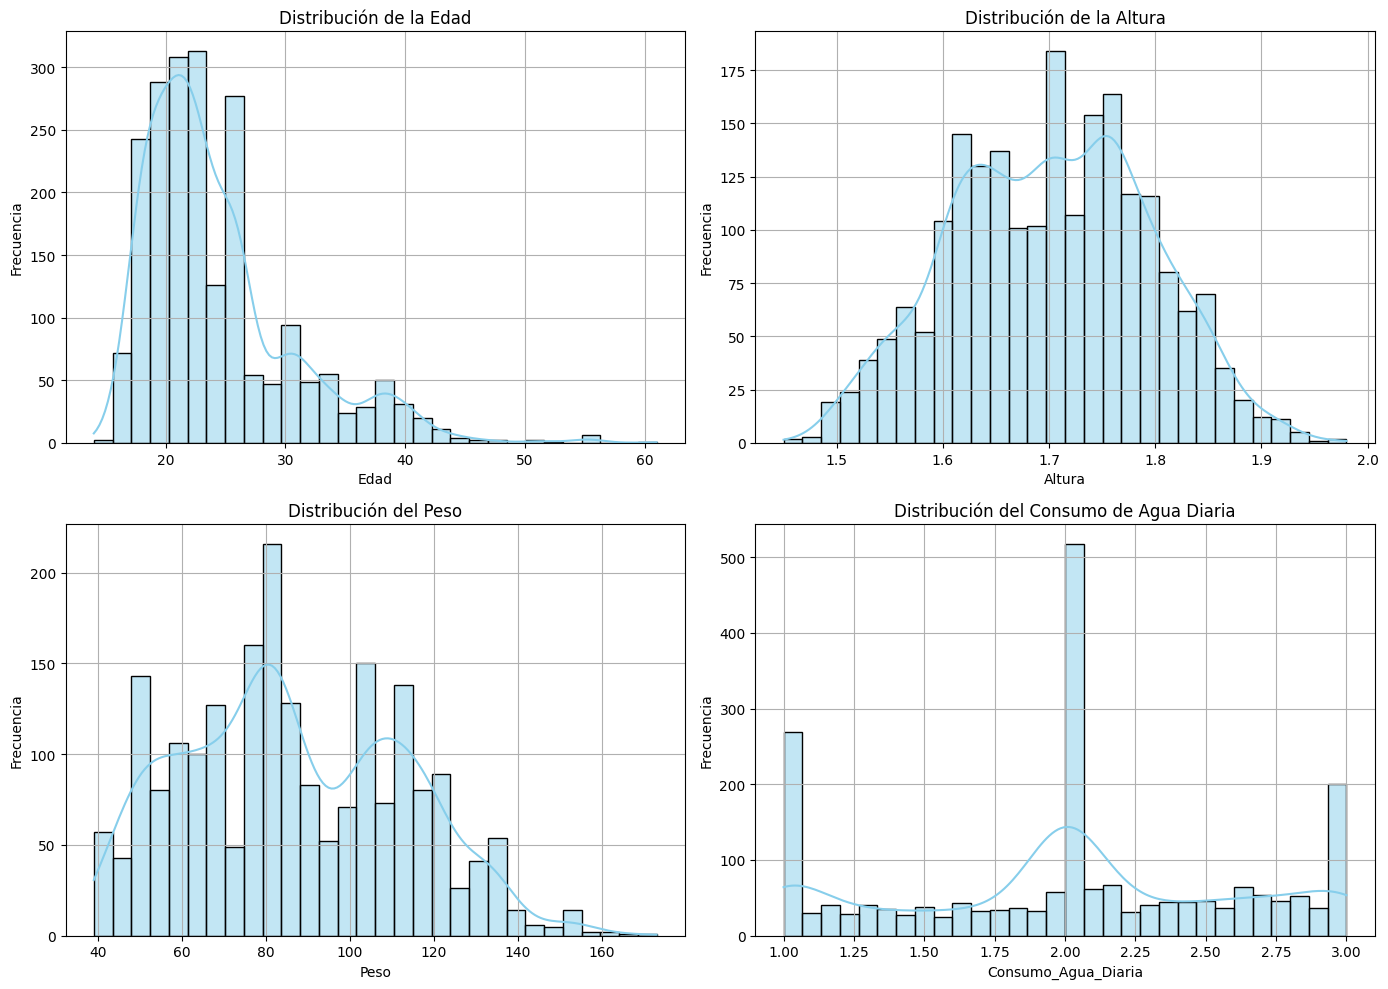

In [52]:
# Variables numéricas para analizar su distribución
variables_a_graficar = ['Edad', 'Altura', 'Peso', 'Consumo_Agua_Diaria']
titulos_histogramas = [
    'Distribución de la Edad',
    'Distribución de la Altura',
    'Distribución del Peso',
    'Distribución del Consumo de Agua Diaria'
]

# Configurar el tamaño de la figura
plt.figure(figsize=(14, 10))

# Bucle para crear los 4 subgráficos
for i, var in enumerate(variables_a_graficar):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=DB_IA, x=var, kde=True, bins=30, color='skyblue')
    plt.title(titulos_histogramas[i])
    plt.xlabel(var)
    plt.ylabel('Frecuencia')
    plt.grid(True)

# Ajustar el diseño para que no se traslapen
plt.tight_layout()
plt.show()

### **Como no hay datos nulos no necesitamos imputar datos**

### **¿Cuándo usar Media vs. Mediana?**

Observando los histogramas anteriores:

*   **Media (Promedio):** Úsala si la distribución es **Simétrica**. En tus gráficos, la *Altura* es la más cercana a esto.
*   **Mediana (Valor Central):** Úsala si la distribución es **Asimétrica** (sesgada) o tiene **Outliers**. En tus gráficos, la *Edad* y el *Peso* muestran un sesgo claro. La mediana no se deja afectar por valores extremos (como una persona de 60 años en un grupo de jóvenes).




¡Esta tabla es tu 'detector de verdad' matemático! Aquí tienes la explicación de lo que nos dicen esos números sobre tus datos:

Peso (Sesgo de 3.58): Es la columna con más ruido. La media es mayor que la mediana, lo que confirma que los outliers (personas de hasta 173 kg) están 'inflando' el promedio. Aquí la Mediana (83 kg) es mucho más real que la Media (86.5 kg).

Edad (Sesgo de 1.53): Al igual que en el peso, la media es más alta. Esto confirma que ese grupito de personas de 60 años está moviendo el promedio hacia arriba. De nuevo, la Mediana (22.7 años) representa mejor a tu grupo joven.

Altura y Agua (Sesgo casi 0): ¡Mira qué belleza! La diferencia es de apenas 0.001 y 0.008. Esto significa que los datos son perfectamente simétricos. Para estas dos variables, puedes usar la Media o la Mediana y el resultado será igual de exacto.

Desviación Estándar: En el Peso (26.1), el número es muy alto, lo que nos alerta que los datos están muy 'regados'. En cambio, en la Altura (0.09), los datos están muy apretaditos cerca del promedio.

Conclusión: Para Peso y Edad, tus cálculos te gritan: '¡Usa la Mediana!'. Para el resto, la Media está perfecta.



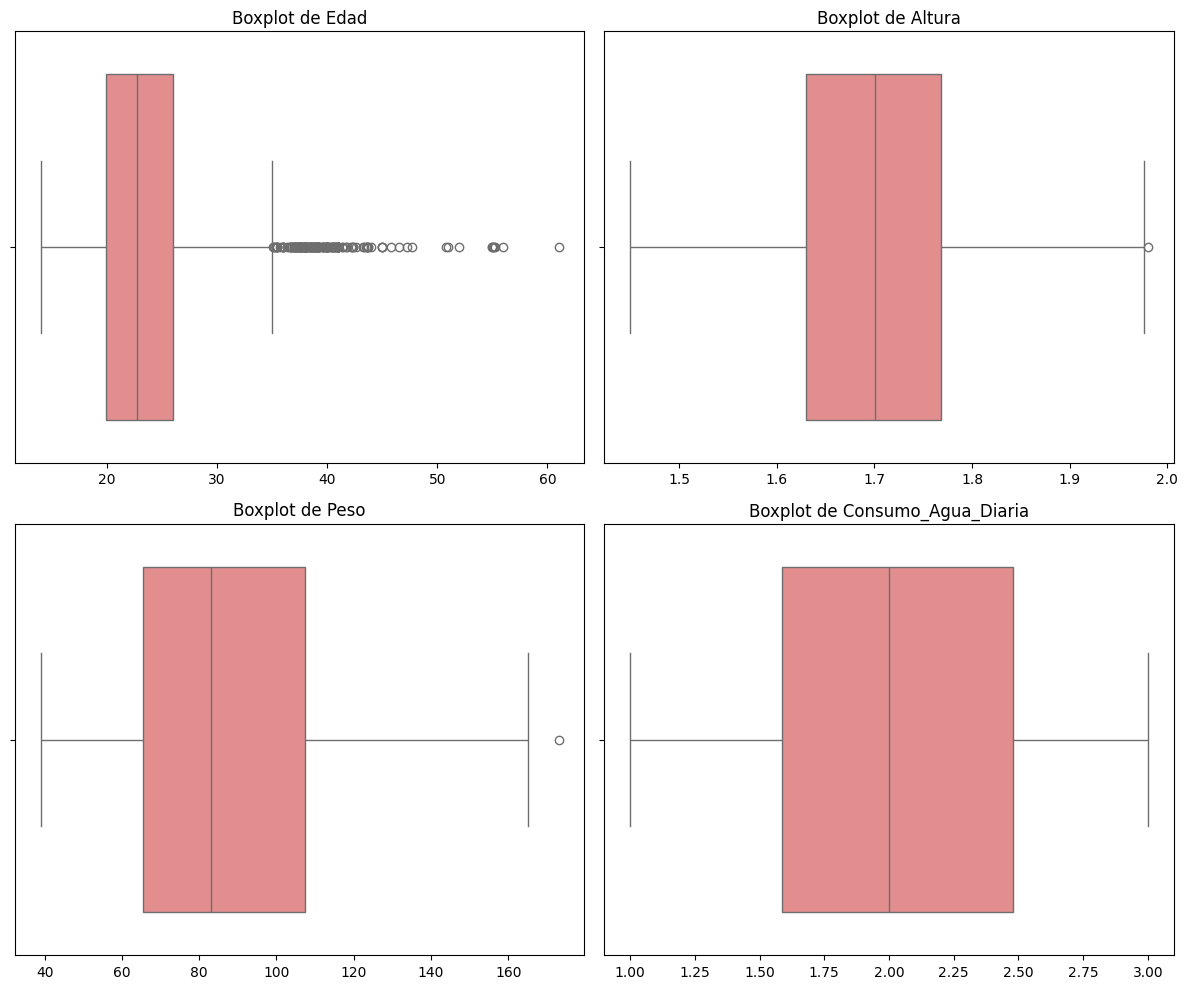

In [54]:
# Variables numéricas para visualizar outliers
variables_numericas = ['Edad', 'Altura', 'Peso', 'Consumo_Agua_Diaria']

# Configurar el tamaño de la figura
plt.figure(figsize=(12, 10))

# Crear un boxplot para cada variable
for i, col in enumerate(variables_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=DB_IA[col], color='lightcoral')
    plt.title(f'Boxplot de {col}')
    plt.xlabel('')

# Ajustar diseño
plt.tight_layout()
plt.show()